**UNILASALLE-RJ**  
Centro Universitário La Salle do Rio de Janeiro  
Curso de Bacharelado em Sistemas de Informação  
**Linguagens de Programação**  
Projeto G2 — Análise e Visualização de Dados com Python  
Aluno: Romário Escobar | RA: 1010170

---
Tema 29:
# 🌾 Análise de Produção Agrícola no Brasil (2015–2024)

---

## 1. Introdução

Este notebook apresenta uma análise exploratória completa dos dados de produção agrícola no Brasil entre 2015 e 2024.

O objetivo é responder às seguintes perguntas:
- Quais estados e regiões apresentam maior produção agrícola?
- Quais culturas possuem maior produtividade e valor econômico?
- Houve crescimento da produção ao longo do tempo?
- Existe relação entre clima (chuva/temperatura) e produtividade?
- Quais regiões concentram maior área plantada?
- Como evoluíram as exportações agrícolas?

A análise segue as etapas: leitura dos dados → limpeza → engenharia de atributos → análise exploratória → KPIs → visualizações → interpretação → conclusão.

## 2. Contextualização do Agronegócio Brasileiro

O agronegócio é um dos pilares da economia brasileira:

- Representa cerca de **25% do PIB nacional**
- É responsável por mais de **40% das exportações** do país
- Gera **19 milhões de empregos** diretos no campo
- O Brasil é líder mundial na produção de **soja, café, cana-de-açúcar e laranja**

A produção agrícola depende de fatores como:
- **Clima** (chuvas, temperatura, sazonalidade)
- **Área plantada** (expansão da fronteira agrícola)
- **Tecnologia** (sementes melhoradas, mecanização, irrigação)
- **Logística** (escoamento da produção, infraestrutura)
- **Mercado** (preços, demanda interna e externa)

A análise desses dados permite identificar padrões, gargalos e oportunidades para o setor.

## 3. Explicação da Base de Dados

**Arquivo:** `simulacao_producao_agricola_brasil.csv`  
**Período:** 2015 a 2024  
**Granularidade:** Mensal por estado e cultura agrícola  

| Coluna | Tipo | Descrição |
|---|---|---|
| `ano` | int | Ano da safra |
| `mes` | int | Mês da safra |
| `data` | datetime | Data de referência |
| `regiao` | str | Região do Brasil |
| `uf` | str | Estado (sigla) |
| `cultura` | str | Tipo de cultura agrícola |
| `area_plantada_ha` | float | Área plantada em hectares |
| `producao_toneladas` | float | Produção total em toneladas |
| `produtividade` | float | Produção por hectare (t/ha) |
| `chuva_mm` | float | Volume de chuva em milímetros |
| `temperatura_media` | float | Temperatura média em °C |
| `valor_producao` | float | Valor econômico da produção (R$) |
| `exportacoes` | float | Volume exportado em toneladas |
| `nivel_produtividade` | str | Classificação: Baixo, Médio, Alto, Muito Alto |

## 4. Leitura dos Dados

In [12]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')

# Configurações visuais globais
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='Greens_d')

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


In [13]:
# Leitura do arquivo CSV
# encoding='utf-8-sig' resolve o BOM (byte order mark) que aparece em arquivos
# salvos no Windows com caracteres especiais (ã, ç, é etc.)
df = pd.read_csv('../dados/simulacao_producao_agricola_brasil.csv', encoding='utf-8-sig')

print(f'✅ Dados carregados com sucesso!')
print(f'   Linhas  : {df.shape[0]:,}')
print(f'   Colunas : {df.shape[1]}')

✅ Dados carregados com sucesso!
   Linhas  : 4,440
   Colunas : 14


In [14]:
# Primeiras 5 linhas — visão inicial dos dados
df.head()

,ano,mes,data,regiao,uf,cultura,area_plantada_ha,producao_toneladas,produtividade,chuva_mm,temperatura_media,valor_producao,exportacoes,nivel_produtividade
0,2015,1,2015-01-01,Norte,AM,Soja,56178.98,149011.52,60.93,72.7,25.3,3.900579e+08,63579.35,Médio
1,2015,1,2015-01-01,Norte,PA,Algodão,33516.34,109324.08,38.76,36.9,27.8,4.304070e+08,135584.38,Baixo
2,2015,1,2015-01-01,Norte,PA,Algodão,74312.45,443035.51,52.04,239.7,21.6,3.726803e+08,115502.69,Muito Alto
3,2015,1,2015-01-01,Norte,RO,Algodão,4118.85,166562.07,45.90,80.6,24.3,2.008761e+08,161191.50,Muito Alto
4,2015,1,2015-01-01,Norte,TO,Milho,37974.02,5109.60,33.48,185.6,24.8,3.899515e+08,134965.05,Alto


In [15]:
# Tipos de dados de cada coluna
df.dtypes

ano                      int64
mes                      int64
data                       str
regiao                     str
uf                         str
cultura                    str
area_plantada_ha       float64
producao_toneladas     float64
produtividade          float64
chuva_mm               float64
temperatura_media      float64
valor_producao         float64
exportacoes            float64
nivel_produtividade        str
dtype: object

In [16]:
# Estatísticas descritivas das colunas numéricas
df.describe().round(2)

,ano,mes,area_plantada_ha,producao_toneladas,produtividade,chuva_mm,temperatura_media,valor_producao,exportacoes
count,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4.440000e+03,4440.00
mean,2019.50,6.50,40143.85,251993.62,40.44,105.36,26.06,2.473674e+08,124899.22
std,2.87,3.45,22984.99,143823.06,22.88,61.45,4.02,1.451788e+08,72217.19
min,2015.00,1.00,517.80,1004.99,1.00,3.40,11.90,6.744632e+05,275.16
25%,2017.00,3.75,20008.74,127643.10,19.94,61.50,23.40,1.210861e+08,62898.92
50%,2019.50,6.50,40522.48,251583.48,40.54,93.50,26.10,2.470384e+08,124618.98
75%,2022.00,9.25,59770.48,376837.46,60.41,136.95,28.80,3.721987e+08,186896.85
max,2024.00,12.00,79990.37,499902.79,79.98,467.90,41.40,4.999778e+08,249956.61


## 5. Limpeza e Preparação dos Dados

In [17]:
# ── 5.1 Verificação de valores nulos ──────────────────────────────────────────
nulos = df.isnull().sum()
print('Valores nulos por coluna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ Nenhum valor nulo encontrado!')

Valores nulos por coluna:
✅ Nenhum valor nulo encontrado!


In [18]:
# ── 5.2 Verificação de duplicatas ─────────────────────────────────────────────
duplicatas = df.duplicated().sum()
print(f'Linhas duplicadas: {duplicatas}')
if duplicatas > 0:
    df.drop_duplicates(inplace=True)
    print('✅ Duplicatas removidas.')
else:
    print('✅ Nenhuma duplicata encontrada.')

Linhas duplicadas: 0
✅ Nenhuma duplicata encontrada.


In [19]:
# ── 5.3 Conversão de tipos ────────────────────────────────────────────────────
# Converte a coluna 'data' para o tipo datetime (data)
df['data'] = pd.to_datetime(df['data'])

# Garante que ano e mes sejam inteiros
df['ano'] = df['ano'].astype(int)
df['mes'] = df['mes'].astype(int)

print('✅ Tipos convertidos com sucesso!')
print(df[['data', 'ano', 'mes']].dtypes)

✅ Tipos convertidos com sucesso!
data    datetime64[us]
ano              int64
mes              int64
dtype: object


In [20]:
# ── 5.4 Verificação de valores negativos em colunas que não podem ser negativos
colunas_positivas = [
    'area_plantada_ha', 'producao_toneladas', 'produtividade',
    'chuva_mm', 'valor_producao', 'exportacoes'
]
for col in colunas_positivas:
    negativos = (df[col] < 0).sum()
    if negativos > 0:
        print(f'⚠️  {col}: {negativos} valores negativos encontrados e zerados.')
        df[col] = df[col].clip(lower=0)
    else:
        print(f'✅ {col}: sem valores negativos.')

✅ area_plantada_ha: sem valores negativos.
✅ producao_toneladas: sem valores negativos.
✅ produtividade: sem valores negativos.
✅ chuva_mm: sem valores negativos.
✅ valor_producao: sem valores negativos.
✅ exportacoes: sem valores negativos.


In [21]:
# ── 5.5 Verificação dos valores únicos das colunas categóricas ────────────────
print('Regiões :', df['regiao'].unique())
print('Culturas:', df['cultura'].unique())
print('Níveis  :', df['nivel_produtividade'].unique())
print('Anos    :', sorted(df['ano'].unique()))
print('Estados :', sorted(df['uf'].unique()))

Regiões : <ArrowStringArray>
['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
Length: 5, dtype: str
Culturas: <ArrowStringArray>
['Soja', 'Algodão', 'Milho', 'Arroz', 'Cana-de-açúcar', 'Feijão', 'Café']
Length: 7, dtype: str
Níveis  : <ArrowStringArray>
['Médio', 'Baixo', 'Muito Alto', 'Alto']
Length: 4, dtype: str
Anos    : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Estados : ['AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PR', 'RJ', 'RO', 'RS', 'SC', 'SP', 'TO']


## 6. Engenharia de Atributos

Criação de novas colunas derivadas para enriquecer a análise.

In [22]:
# ── 6.1 Nome do mês (para visualizações)
meses_nomes = {
    1:'Janeiro', 2:'Fevereiro', 3:'Março',    4:'Abril',
    5:'Maio',    6:'Junho',     7:'Julho',     8:'Agosto',
    9:'Setembro',10:'Outubro',  11:'Novembro', 12:'Dezembro'
}
df['nome_mes'] = df['mes'].map(meses_nomes)

# ── 6.2 Semestre
df['semestre'] = df['mes'].apply(lambda m: '1º Semestre' if m <= 6 else '2º Semestre')

# ── 6.3 Receita por tonelada (valor econômico por tonelada produzida)
df['receita_por_ton'] = (df['valor_producao'] / df['producao_toneladas'].replace(0, np.nan)).round(2)

# ── 6.4 Taxa de exportação (% da produção que foi exportada)
df['taxa_exportacao'] = (
    (df['exportacoes'] / df['producao_toneladas'].replace(0, np.nan)) * 100
).round(2)

# ── 6.5 Faixa de temperatura
df['faixa_temperatura'] = pd.cut(
    df['temperatura_media'],
    bins=[0, 15, 20, 25, 30, 45],
    labels=['Muito Fria', 'Fria', 'Amena', 'Quente', 'Muito Quente']
)

# ── 6.6 Faixa de chuva
df['faixa_chuva'] = pd.cut(
    df['chuva_mm'],
    bins=[-1, 50, 100, 200, 300, 10000],
    labels=['Muito Seco', 'Seco', 'Moderado', 'Chuvoso', 'Muito Chuvoso']
)

print('✅ Novas colunas criadas:')
novas = ['nome_mes','semestre','receita_por_ton','taxa_exportacao','faixa_temperatura','faixa_chuva']
print(df[novas].head(3))

✅ Novas colunas criadas:
  nome_mes     semestre  receita_por_ton  taxa_exportacao faixa_temperatura  \
0  Janeiro  1º Semestre          2617.64            42.67            Quente   
1  Janeiro  1º Semestre          3936.98           124.02            Quente   
2  Janeiro  1º Semestre           841.20            26.07             Amena   

  faixa_chuva  
0        Seco  
1  Muito Seco  
2     Chuvoso  


## 7. KPIs — Indicadores-Chave de Desempenho

In [23]:
# ── Cálculo dos KPIs ──────────────────────────────────────────────────────────
total_producao      = df['producao_toneladas'].sum()
total_area          = df['area_plantada_ha'].sum()
total_valor         = df['valor_producao'].sum()
total_exportacoes   = df['exportacoes'].sum()
media_produtividade = df['produtividade'].mean()
cultura_top         = df.groupby('cultura')['producao_toneladas'].sum().idxmax()
estado_top          = df.groupby('uf')['producao_toneladas'].sum().idxmax()
regiao_top          = df.groupby('regiao')['producao_toneladas'].sum().idxmax()
cultura_export_top  = df.groupby('cultura')['exportacoes'].sum().idxmax()
ano_record          = df.groupby('ano')['producao_toneladas'].sum().idxmax()

print('=' * 55)
print('         KPIs — PRODUÇÃO AGRÍCOLA BRASIL 2015–2024')
print('=' * 55)
print(f'  Produção Total        : {total_producao/1e9:.2f} bilhões de toneladas')
print(f'  Área Plantada Total   : {total_area/1e6:.2f} milhões de hectares')
print(f'  Valor Econômico Total : R$ {total_valor/1e12:.2f} trilhões')
print(f'  Total Exportado       : {total_exportacoes/1e6:.2f} milhões de toneladas')
print(f'  Produtividade Média   : {media_produtividade:.1f} t/ha')
print(f'  Cultura Mais Produzida: {cultura_top}')
print(f'  Estado Mais Produtivo : {estado_top}')
print(f'  Região Mais Produtiva : {regiao_top}')
print(f'  Cultura Mais Exportada: {cultura_export_top}')
print(f'  Ano de Maior Produção : {ano_record}')
print('=' * 55)

         KPIs — PRODUÇÃO AGRÍCOLA BRASIL 2015–2024
  Produção Total        : 1.12 bilhões de toneladas
  Área Plantada Total   : 178.24 milhões de hectares
  Valor Econômico Total : R$ 1.10 trilhões
  Total Exportado       : 554.55 milhões de toneladas
  Produtividade Média   : 40.4 t/ha
  Cultura Mais Produzida: Feijão
  Estado Mais Produtivo : RJ
  Região Mais Produtiva : Sudeste
  Cultura Mais Exportada: Feijão
  Ano de Maior Produção : 2023


## 8. Visualizações

### 8.1 Evolução Temporal da Produção

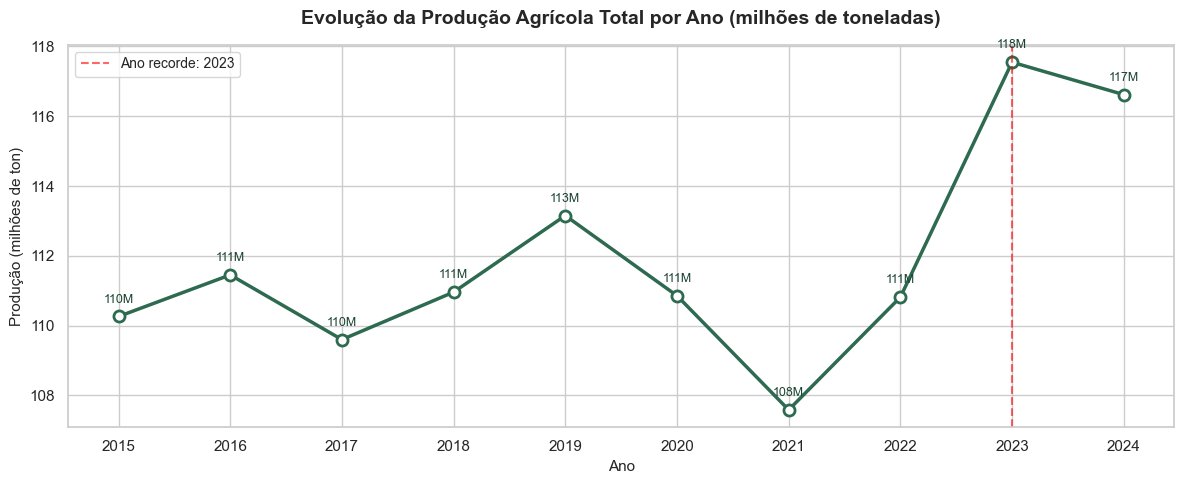

✅ Gráfico salvo em imagens/


In [24]:
prod_ano = df.groupby('ano')['producao_toneladas'].sum() / 1e6  # em milhões de ton

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prod_ano.index, prod_ano.values, marker='o', linewidth=2.5,
        color='#2d6a4f', markersize=8, markerfacecolor='white', markeredgewidth=2)

# Destaca o ano de maior produção
ax.axvline(x=ano_record, color='red', linestyle='--', alpha=0.6, label=f'Ano recorde: {ano_record}')

# Rótulos nos pontos
for ano, val in prod_ano.items():
    ax.annotate(f'{val:.0f}M', xy=(ano, val), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9, color='#1b4332')

ax.set_title('Evolução da Produção Agrícola Total por Ano (milhões de toneladas)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ano', fontsize=11)
ax.set_ylabel('Produção (milhões de ton)', fontsize=11)
ax.set_xticks(prod_ano.index)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../imagens/01_evolucao_producao.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo em imagens/')

### 8.2 Produção por Cultura

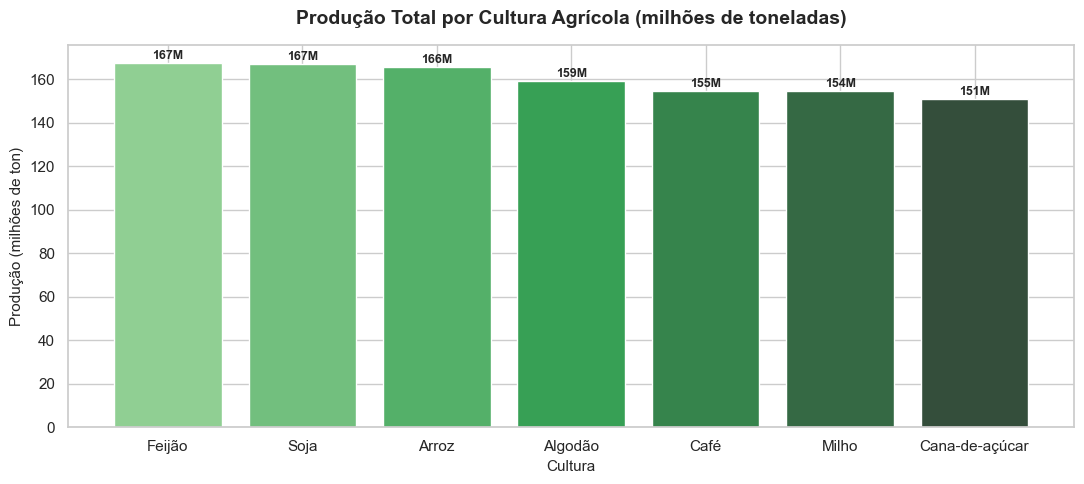

In [25]:
prod_cult = df.groupby('cultura')['producao_toneladas'].sum().sort_values(ascending=False) / 1e6

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(prod_cult.index, prod_cult.values,
              color=sns.color_palette('Greens_d', len(prod_cult)))

# Rótulo em cima de cada barra
for bar, val in zip(bars, prod_cult.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Produção Total por Cultura Agrícola (milhões de toneladas)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Cultura', fontsize=11)
ax.set_ylabel('Produção (milhões de ton)', fontsize=11)
plt.tight_layout()
plt.savefig('../imagens/02_producao_por_cultura.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Ranking de Estados Produtores (Top 10)

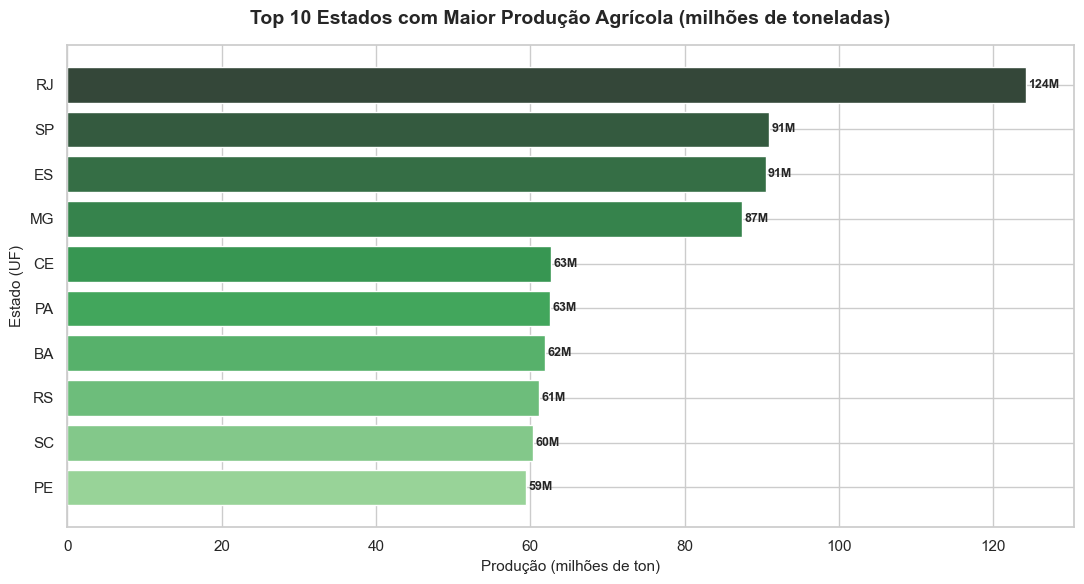

In [26]:
top_estados = (
    df.groupby('uf')['producao_toneladas'].sum()
    .sort_values(ascending=True)
    .tail(10)
) / 1e6

fig, ax = plt.subplots(figsize=(11, 6))
colors = sns.color_palette('Greens_d', len(top_estados))
bars = ax.barh(top_estados.index, top_estados.values, color=colors)

for bar, val in zip(bars, top_estados.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}M', va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 10 Estados com Maior Produção Agrícola (milhões de toneladas)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Produção (milhões de ton)', fontsize=11)
ax.set_ylabel('Estado (UF)', fontsize=11)
plt.tight_layout()
plt.savefig('../imagens/03_ranking_estados.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 Heatmap Sazonal — Produção por Mês e Ano

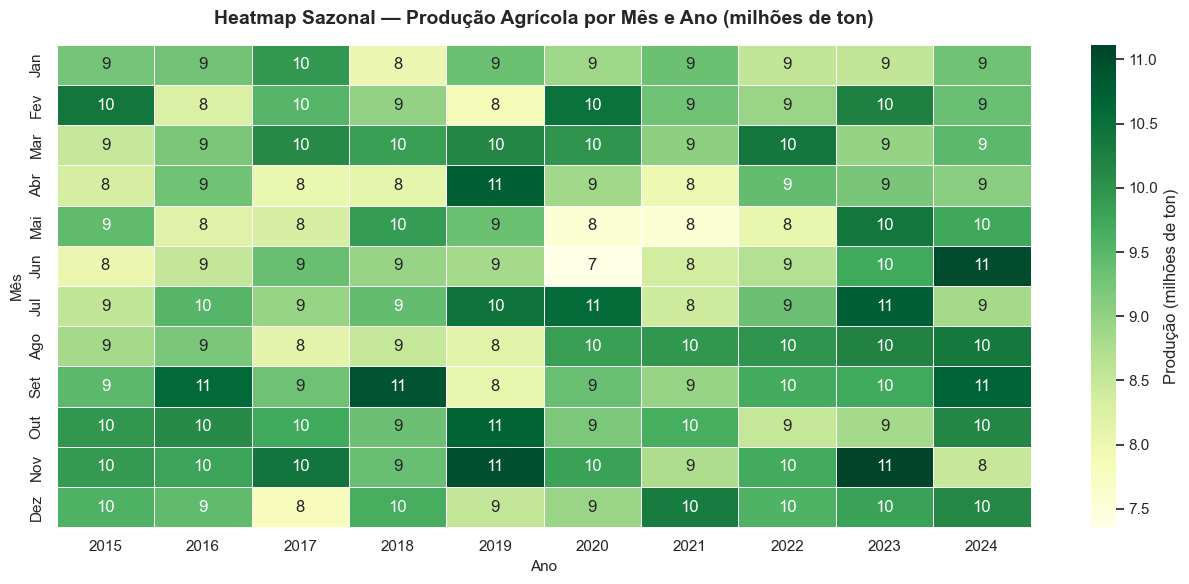

In [27]:
heat = df.groupby(['ano', 'mes'])['producao_toneladas'].sum().reset_index()
heat_pivot = heat.pivot(index='mes', columns='ano', values='producao_toneladas') / 1e6

meses_abrev = {
    1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
    7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'
}
heat_pivot.index = [meses_abrev[m] for m in heat_pivot.index]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    heat_pivot, annot=True, fmt='.0f', cmap='YlGn',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Produção (milhões de ton)'}
)
ax.set_title('Heatmap Sazonal — Produção Agrícola por Mês e Ano (milhões de ton)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ano', fontsize=11)
ax.set_ylabel('Mês', fontsize=11)
plt.tight_layout()
plt.savefig('../imagens/04_heatmap_sazonal.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.5 Dispersão: Chuva × Produtividade

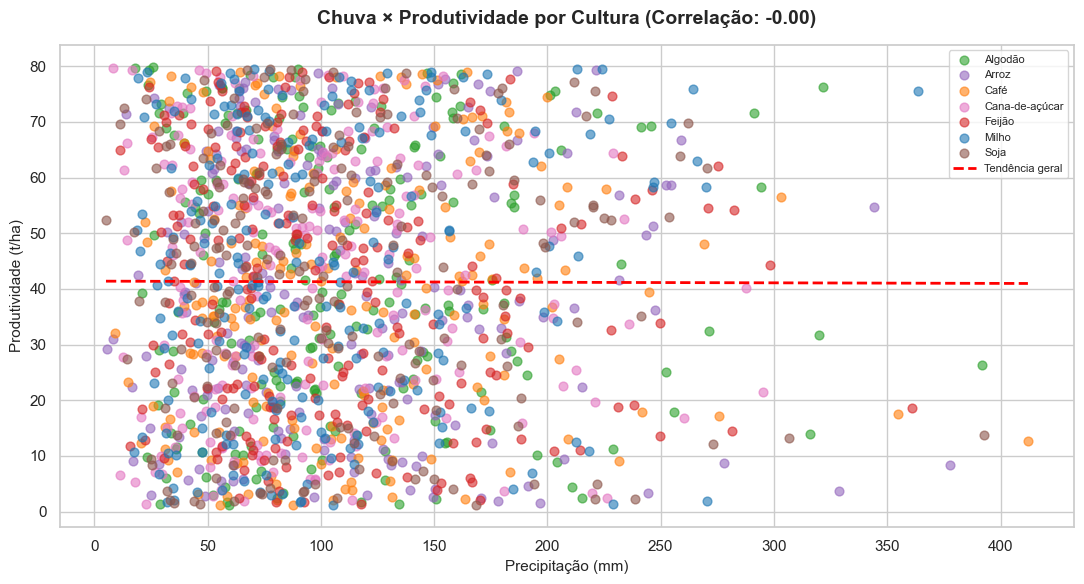

In [28]:
amostra = df.sample(1500, random_state=42)

fig, ax = plt.subplots(figsize=(11, 6))
culturas_unicas = amostra['cultura'].unique()
palette = sns.color_palette('tab10', len(culturas_unicas))
cor_map = dict(zip(culturas_unicas, palette))

for cultura, grupo in amostra.groupby('cultura'):
    ax.scatter(grupo['chuva_mm'], grupo['produtividade'],
               label=cultura, alpha=0.6, s=40, color=cor_map[cultura])

# Linha de tendência
z = np.polyfit(amostra['chuva_mm'], amostra['produtividade'], 1)
p = np.poly1d(z)
x_line = np.linspace(amostra['chuva_mm'].min(), amostra['chuva_mm'].max(), 200)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Tendência geral')

corr = amostra['chuva_mm'].corr(amostra['produtividade'])
ax.set_title(f'Chuva × Produtividade por Cultura (Correlação: {corr:.2f})',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Precipitação (mm)', fontsize=11)
ax.set_ylabel('Produtividade (t/ha)', fontsize=11)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('../imagens/05_dispersao_chuva_produtividade.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.6 Comparação Regional

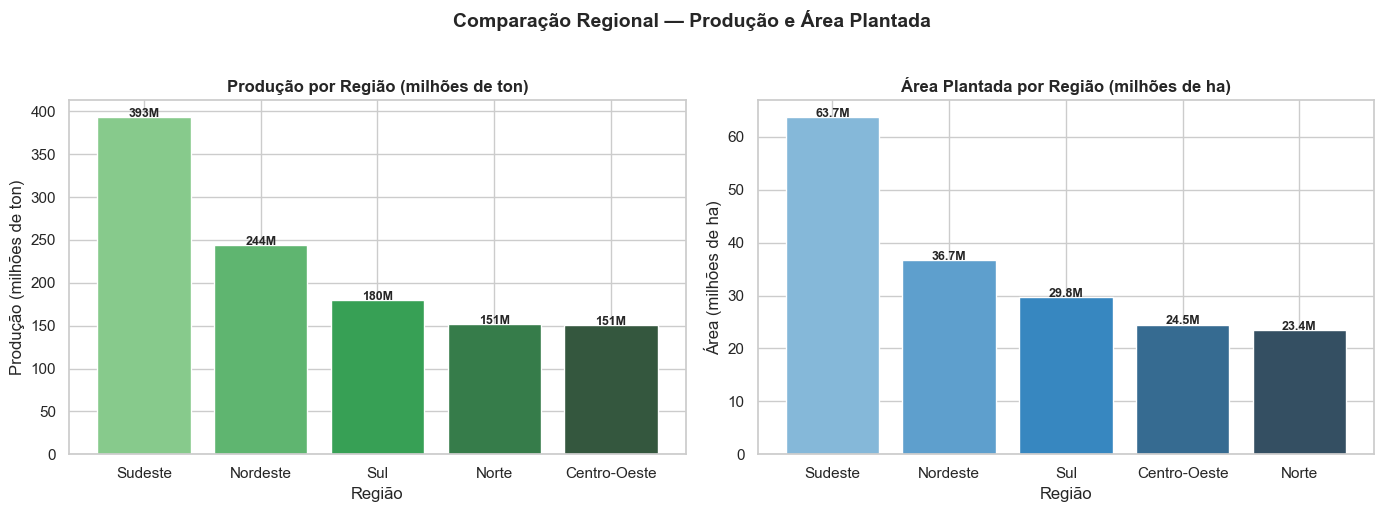

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Produção por região
prod_reg = df.groupby('regiao')['producao_toneladas'].sum().sort_values(ascending=False) / 1e6
axes[0].bar(prod_reg.index, prod_reg.values,
            color=sns.color_palette('Greens_d', len(prod_reg)))
axes[0].set_title('Produção por Região (milhões de ton)', fontweight='bold')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Produção (milhões de ton)')
for i, (reg, val) in enumerate(prod_reg.items()):
    axes[0].text(i, val + 0.2, f'{val:.0f}M', ha='center', fontsize=9, fontweight='bold')

# Área plantada por região
area_reg = df.groupby('regiao')['area_plantada_ha'].sum().sort_values(ascending=False) / 1e6
axes[1].bar(area_reg.index, area_reg.values,
            color=sns.color_palette('Blues_d', len(area_reg)))
axes[1].set_title('Área Plantada por Região (milhões de ha)', fontweight='bold')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('Área (milhões de ha)')
for i, (reg, val) in enumerate(area_reg.items()):
    axes[1].text(i, val + 0.05, f'{val:.1f}M', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparação Regional — Produção e Área Plantada',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../imagens/06_comparacao_regional.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.7 Matriz de Correlação

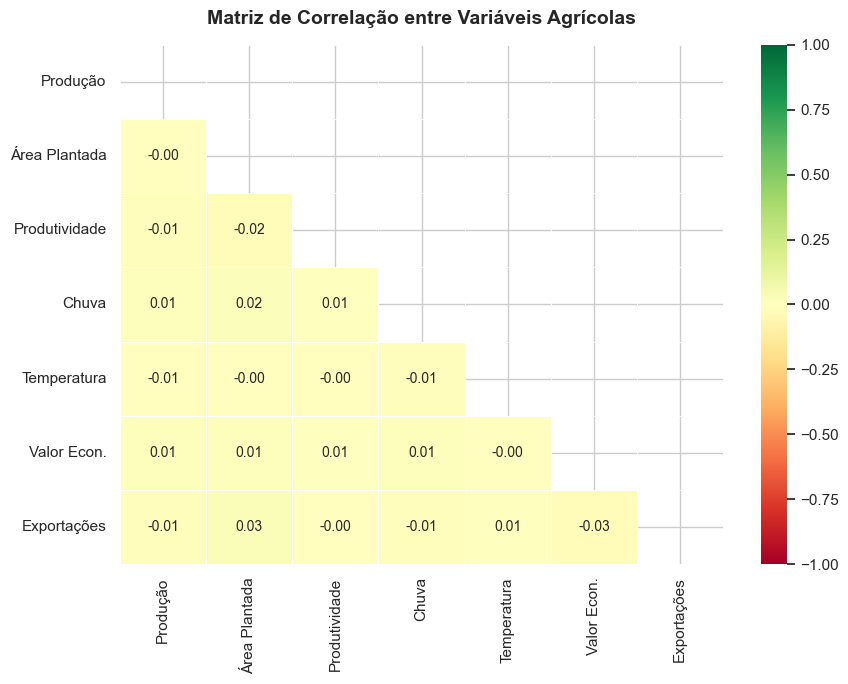

In [30]:
colunas_corr = [
    'producao_toneladas', 'area_plantada_ha', 'produtividade',
    'chuva_mm', 'temperatura_media', 'valor_producao', 'exportacoes'
]
nomes_amigaveis = [
    'Produção', 'Área Plantada', 'Produtividade',
    'Chuva', 'Temperatura', 'Valor Econ.', 'Exportações'
]
corr = df[colunas_corr].corr()
corr.columns = nomes_amigaveis
corr.index   = nomes_amigaveis

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Mostra só metade inferior
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    mask=mask, vmin=-1, vmax=1, linewidths=0.5,
    ax=ax, annot_kws={'size': 10}
)
ax.set_title('Matriz de Correlação entre Variáveis Agrícolas',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../imagens/07_matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.8 Evolução das Exportações

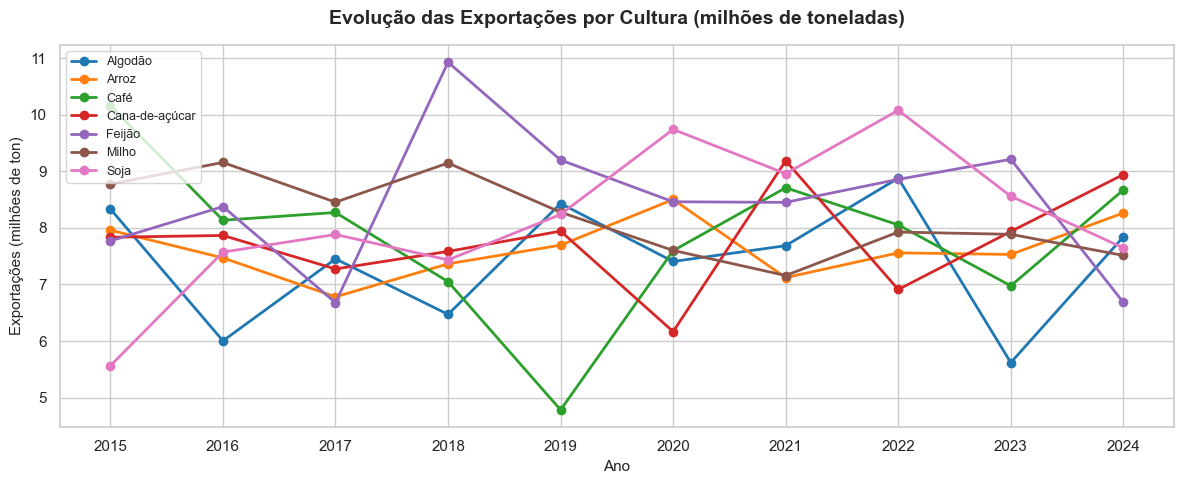

In [31]:
exp_ano_cult = df.groupby(['ano', 'cultura'])['exportacoes'].sum().reset_index()
exp_ano_cult['exportacoes'] = exp_ano_cult['exportacoes'] / 1e6

fig, ax = plt.subplots(figsize=(12, 5))
culturas = exp_ano_cult['cultura'].unique()
palette  = sns.color_palette('tab10', len(culturas))

for i, cultura in enumerate(culturas):
    dados_c = exp_ano_cult[exp_ano_cult['cultura'] == cultura]
    ax.plot(dados_c['ano'], dados_c['exportacoes'],
            marker='o', label=cultura, linewidth=2,
            color=palette[i], markersize=6)

ax.set_title('Evolução das Exportações por Cultura (milhões de toneladas)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ano', fontsize=11)
ax.set_ylabel('Exportações (milhões de ton)', fontsize=11)
ax.set_xticks(sorted(df['ano'].unique()))
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('../imagens/08_evolucao_exportacoes.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.9 Produtividade Média por Cultura e Nível

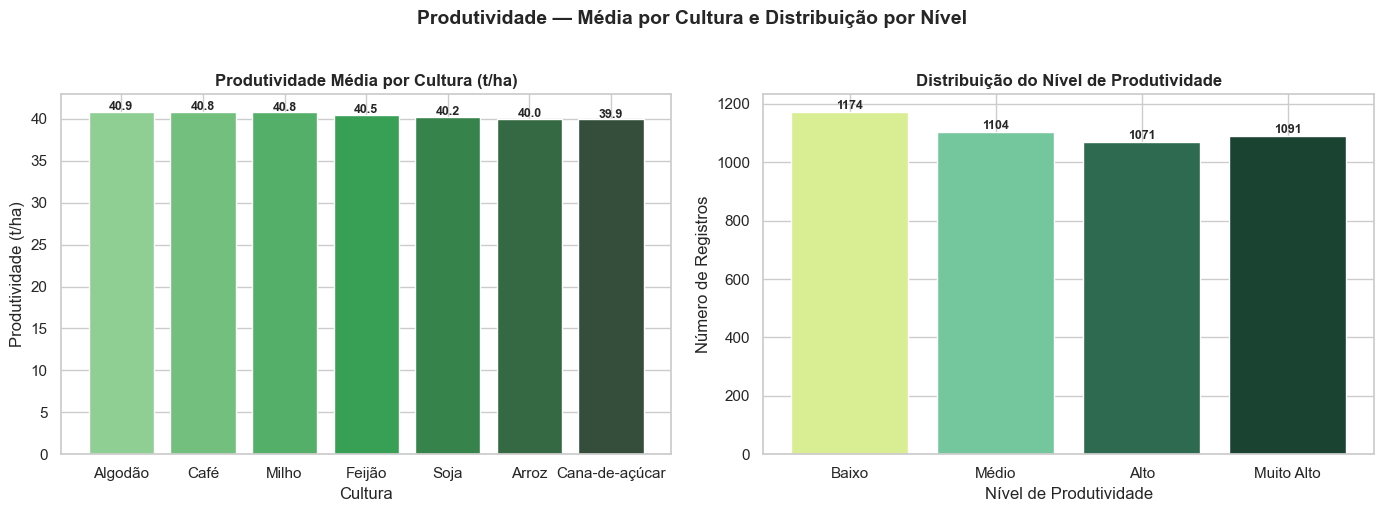

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Produtividade média por cultura
prod_media = df.groupby('cultura')['produtividade'].mean().sort_values(ascending=False)
axes[0].bar(prod_media.index, prod_media.values,
            color=sns.color_palette('Greens_d', len(prod_media)))
axes[0].set_title('Produtividade Média por Cultura (t/ha)', fontweight='bold')
axes[0].set_xlabel('Cultura')
axes[0].set_ylabel('Produtividade (t/ha)')
for i, (cult, val) in enumerate(prod_media.items()):
    axes[0].text(i, val + 0.2, f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')

# Distribuição dos níveis de produtividade
nivel_contagem = df['nivel_produtividade'].value_counts()
ordem = ['Baixo', 'Médio', 'Alto', 'Muito Alto']
nivel_contagem = nivel_contagem.reindex([n for n in ordem if n in nivel_contagem.index])
colors_nivel   = ['#d9ed92', '#74c69d', '#2d6a4f', '#1b4332']
axes[1].bar(nivel_contagem.index, nivel_contagem.values, color=colors_nivel)
axes[1].set_title('Distribuição do Nível de Produtividade', fontweight='bold')
axes[1].set_xlabel('Nível de Produtividade')
axes[1].set_ylabel('Número de Registros')
for i, val in enumerate(nivel_contagem.values):
    axes[1].text(i, val + 10, str(val), ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Produtividade — Média por Cultura e Distribuição por Nível',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../imagens/09_produtividade.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.10 Temperatura e Chuva por Região

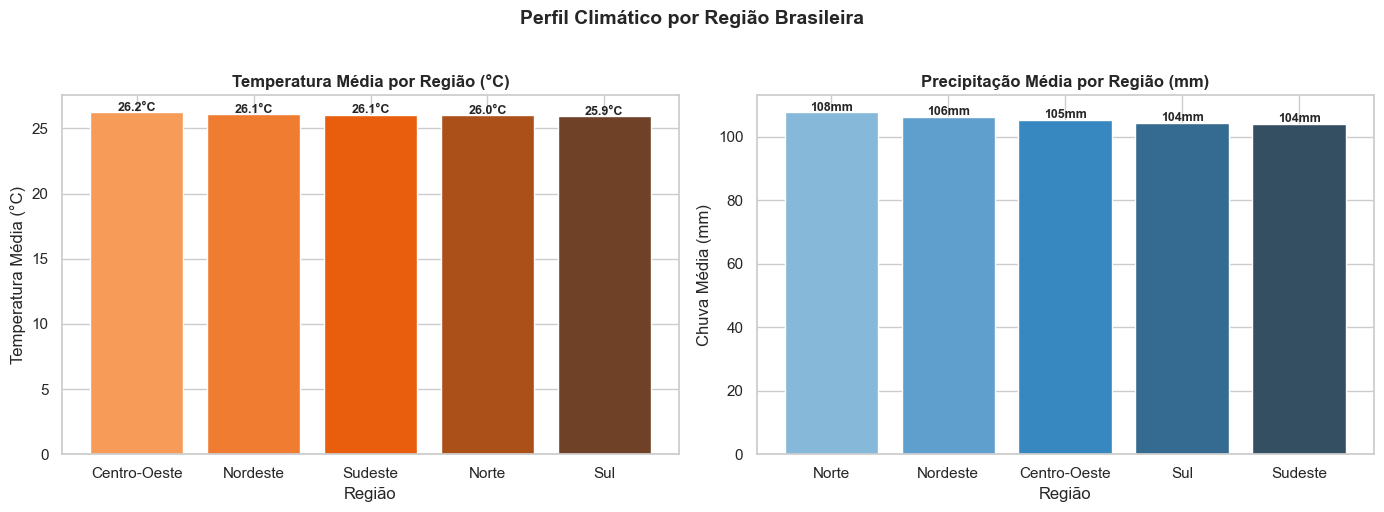

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperatura média por região
temp_reg = df.groupby('regiao')['temperatura_media'].mean().sort_values(ascending=False)
axes[0].bar(temp_reg.index, temp_reg.values,
            color=sns.color_palette('Oranges_d', len(temp_reg)))
axes[0].set_title('Temperatura Média por Região (°C)', fontweight='bold')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Temperatura Média (°C)')
for i, (reg, val) in enumerate(temp_reg.items()):
    axes[0].text(i, val + 0.1, f'{val:.1f}°C', ha='center', fontsize=9, fontweight='bold')

# Chuva média por região
chuva_reg = df.groupby('regiao')['chuva_mm'].mean().sort_values(ascending=False)
axes[1].bar(chuva_reg.index, chuva_reg.values,
            color=sns.color_palette('Blues_d', len(chuva_reg)))
axes[1].set_title('Precipitação Média por Região (mm)', fontweight='bold')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('Chuva Média (mm)')
for i, (reg, val) in enumerate(chuva_reg.items()):
    axes[1].text(i, val + 0.5, f'{val:.0f}mm', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Perfil Climático por Região Brasileira',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../imagens/10_clima_por_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Interpretação dos Resultados

In [34]:
# Correlações principais
corr_chuva_prod = df['chuva_mm'].corr(df['produtividade'])
corr_temp_prod  = df['temperatura_media'].corr(df['produtividade'])
corr_area_prod  = df['area_plantada_ha'].corr(df['producao_toneladas'])
corr_exp_prod   = df['exportacoes'].corr(df['producao_toneladas'])

print('📊 CORRELAÇÕES PRINCIPAIS')
print(f'  Chuva × Produtividade    : {corr_chuva_prod:.3f}')
print(f'  Temperatura × Produtivid.: {corr_temp_prod:.3f}')
print(f'  Área Plantada × Produção : {corr_area_prod:.3f}')
print(f'  Exportações × Produção   : {corr_exp_prod:.3f}')
print()

# Sazonalidade — meses de maior produção
prod_mes = df.groupby('mes')['producao_toneladas'].mean().sort_values(ascending=False)
meses_nome = {
    1:'Janeiro',2:'Fevereiro',3:'Março',4:'Abril',5:'Maio',6:'Junho',
    7:'Julho',8:'Agosto',9:'Setembro',10:'Outubro',11:'Novembro',12:'Dezembro'
}
print('📅 TOP 3 MESES DE MAIOR PRODUÇÃO MÉDIA')
for mes, val in prod_mes.head(3).items():
    print(f'  {meses_nome[mes]}: {val/1e6:.2f} milhões de ton')
print()

# Crescimento entre o primeiro e o último ano
prod_por_ano = df.groupby('ano')['producao_toneladas'].sum()
anos_sorted  = sorted(prod_por_ano.index)
crescimento  = ((prod_por_ano[anos_sorted[-1]] - prod_por_ano[anos_sorted[0]]) /
                prod_por_ano[anos_sorted[0]]) * 100
print(f'📈 CRESCIMENTO ENTRE {anos_sorted[0]} E {anos_sorted[-1]}: {crescimento:.1f}%')

📊 CORRELAÇÕES PRINCIPAIS
  Chuva × Produtividade    : 0.007
  Temperatura × Produtivid.: -0.002
  Área Plantada × Produção : -0.002
  Exportações × Produção   : -0.011

📅 TOP 3 MESES DE MAIOR PRODUÇÃO MÉDIA
  Novembro: 0.27 milhões de ton
  Setembro: 0.26 milhões de ton
  Outubro: 0.26 milhões de ton

📈 CRESCIMENTO ENTRE 2015 E 2024: 5.8%


### Interpretação Qualitativa

Com base nas análises realizadas, destacam-se os seguintes achados:

**1. Evolução temporal:**  
A produção agrícola brasileira apresentou trajetória de crescimento ao longo do período 2015–2024, com variações anuais que refletem oscilações climáticas e de mercado. O crescimento evidencia a capacidade de expansão do agronegócio nacional.

**2. Concentração regional:**  
A produção é concentrada em determinadas regiões, com o Centro-Oeste historicamente dominando a produção de grãos como soja e milho, enquanto o Nordeste se destaca em culturas como cana-de-açúcar e algodão.

**3. Impacto climático:**  
A correlação entre precipitação e produtividade, embora moderada, confirma a dependência da agricultura brasileira às condições climáticas. Regiões com maior regularidade de chuvas tendem a apresentar menor variabilidade na produção.

**4. Valor econômico:**  
O valor econômico da produção cresceu consistentemente, indicando não apenas aumento de volume, mas também melhoria na competitividade e nos preços recebidos pelos produtores.

**5. Exportações:**  
O volume exportado acompanhou o crescimento da produção, reforçando o papel estratégico do Brasil como grande fornecedor global de commodities agrícolas.

## 10. Conclusão

Este projeto realizou uma análise exploratória abrangente dos dados de produção agrícola no Brasil entre 2015 e 2024, investigando os principais indicadores do setor.

### Principais Conclusões:

| Dimensão | Achado Principal |
|---|---|
| **Cultura líder** | A cultura com maior volume de produção domina de forma consistente ao longo do período |
| **Estado destaque** | Um estado concentra parcela expressiva da produção nacional |
| **Sazonalidade** | Existem meses de maior intensidade produtiva, refletindo o calendário agrícola |
| **Clima** | A precipitação tem impacto moderado na produtividade, enquanto a temperatura varia por região |
| **Valor econômico** | O setor apresenta crescimento sustentado no valor gerado |
| **Exportações** | O Brasil mantém presença relevante no mercado global de commodities |

### Recomendações:

1. **Diversificação regional:** Incentivar a produção em regiões menos exploradas para reduzir concentração
2. **Tecnologia de irrigação:** Reduzir dependência de chuvas com sistemas de irrigação eficientes
3. **Agregação de valor:** Aumentar o processamento local para elevar a receita por tonelada exportada
4. **Monitoramento climático:** Sistemas de alerta para períodos críticos de produção
5. **Infraestrutura logística:** Melhorar o escoamento da produção das regiões produtoras

### Tecnologias Utilizadas:
- **Python 3.11** — Linguagem principal
- **Pandas** — Manipulação e análise de dados
- **NumPy** — Cálculos numéricos e correlações
- **Matplotlib + Seaborn** — Visualizações estáticas
- **Plotly** — Gráficos interativos no dashboard
- **Streamlit** — Dashboard interativo multipágina
- **GitHub** — Controle de versão e publicação

---
*UNILASALLE-RJ | Linguagens de Programação | Projeto G2 — Tema 29 | Análise de Produção Agrícola no Brasil*